In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 2 - REINFORCE (Vanilla Policy Gradient)

Starting Training (This will take a few minutes)...
--- Training REINFORCE (Constant Baseline = 0.0 | Seed: 38) ---
Episode  100 | Avg Reward: 72.01 | Last Loss: 2445.34
Episode  200 | Avg Reward: 150.77 | Last Loss: 5442.82
Episode  300 | Avg Reward: 101.05 | Last Loss: 26698.62
Episode  400 | Avg Reward: 134.52 | Last Loss: 25932.23
Episode  500 | Avg Reward: 198.07 | Last Loss: 17985.07
Episode  600 | Avg Reward: 203.37 | Last Loss: 26187.43
Episode  700 | Avg Reward: 192.64 | Last Loss: 30986.30
Episode  800 | Avg Reward: 185.78 | Last Loss: 31314.48
Episode  900 | Avg Reward: 188.15 | Last Loss: 33776.95
Episode 1000 | Avg Reward: 228.06 | Last Loss: 35986.97
--- Training REINFORCE (Constant Baseline = 30.0 | Seed: 38) ---
Episode  100 | Avg Reward: 61.21 | Last Loss: 3463.56
Episode  200 | Avg Reward: 92.42 | Last Loss: 2357.97
Episode  300 | Avg Reward: 151.92 | Last Loss: 20016.89
Episode  400 | Avg Reward: 204.36 | Last Loss: 14138.92
Episode  500 | Avg Reward: 195.28 | Last L

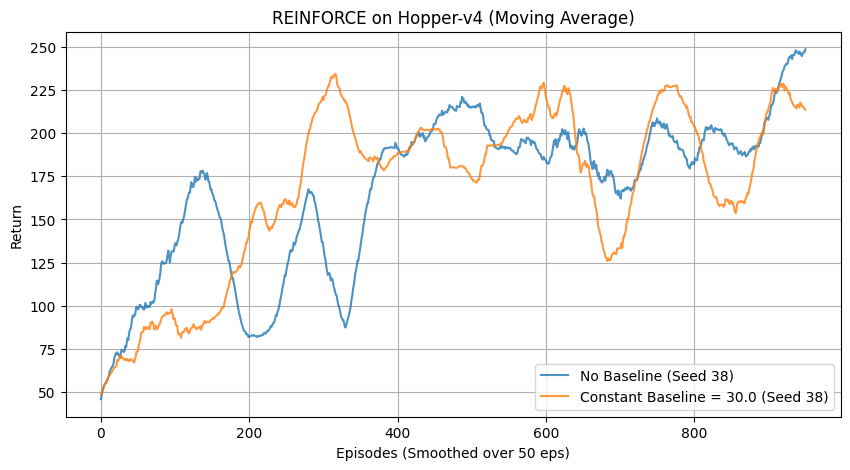

In [18]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import os

# Import your newly updated agent
from agent import ReinforceAgent

# ==========================================
# 3. THE SEED LOCK FUNCTION
# ==========================================
def set_seed(env, seed=38):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ==========================================
# 4. THE TRAINING LOOP
# ==========================================
def train_reinforce(env_name='Hopper-v4', episodes=1000, baseline=0.0, seed=38):
    env = gym.make(env_name)
    set_seed(env, seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    # Instantiate the agent with the requested constant baseline
    agent = ReinforceAgent(state_dim, action_dim, lr=1e-3, gamma=0.99, baseline=baseline)
    metrics_rewards = []

    print(f"--- Training REINFORCE (Constant Baseline = {baseline} | Seed: {seed}) ---")

    for ep in range(episodes):
        if ep == 0:
            state, _ = env.reset(seed=seed)
        else:
            state, _ = env.reset()

        ep_reward = 0

        while True:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            agent.rewards.append(reward)
            ep_reward += reward
            state = next_state

            if terminated or truncated:
                break

        loss = agent.update()
        metrics_rewards.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(metrics_rewards[-100:])
            print(f"Episode {ep + 1:4d} | Avg Reward: {avg_reward:.2f} | Last Loss: {loss:.2f}")

    env.close()
    return metrics_rewards

# ==========================================
# 5. EXECUTION AND PLOTTING
# ==========================================
if __name__ == "__main__":
    print("Starting Training (This will take a few minutes)...")

    # Experiment 1: No baseline
    rewards_no_baseline = train_reinforce(baseline=0.0, seed=38)

    # Experiment 2: Constant Baseline = 30.0
    rewards_const_baseline = train_reinforce(baseline=30.0, seed=38)

    # Plot results with moving average smoothing
    plt.figure(figsize=(10, 5))
    window = 50

    plt.plot(np.convolve(rewards_no_baseline, np.ones(window)/window, mode='valid'),
             alpha=0.8, label='No Baseline (Seed 38)')
    plt.plot(np.convolve(rewards_const_baseline, np.ones(window)/window, mode='valid'),
             alpha=0.8, label='Constant Baseline = 30.0 (Seed 38)')

    plt.title('REINFORCE on Hopper-v4 (Moving Average)')
    plt.xlabel(f'Episodes (Smoothed over {window} eps)')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(True)
    plt.show()

## Task 3 - Actor Critic

In [17]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import os

# Import your agent (change 'critic' to 'agent' if you moved the classes)
from actor_critic import ActorCriticAgent

# ==========================================
# 1. THE SEED LOCK FUNCTION
# ==========================================
def set_seed(env, seed=38):
    """Locks all random number generators for exact reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Force PyTorch to use deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ==========================================
# 2. THE TRAINING LOOP
# ==========================================
def train_actor_critic(env_name='Hopper-v4', episodes=1000, seed=38):
    env = gym.make(env_name)

    # Apply the global seed lock
    set_seed(env, seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = ActorCriticAgent(state_dim, action_dim)
    metrics_rewards = []

    print(f"--- Training ACTOR-CRITIC (Seed: {seed}) ---")
    for ep in range(episodes):

        # Pass the seed to the Gym environment ONLY on the very first reset
        if ep == 0:
            state, _ = env.reset(seed=seed)
        else:
            state, _ = env.reset()

        ep_reward = 0

        while True:
            # We don't pass deterministic=True here because we WANT to explore during training
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            agent.rewards.append(reward)
            ep_reward += reward
            state = next_state

            if terminated or truncated:
                break

        actor_loss, critic_loss = agent.update()
        metrics_rewards.append(ep_reward)

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(metrics_rewards[-100:])
            print(f"Episode {ep+1:4d} | Avg Reward: {avg_reward:.2f} | A-Loss: {actor_loss:.2f} | C-Loss: {critic_loss:.2f}")

    env.close()
    return metrics_rewards

# ==========================================
# 3. EXECUTION AND PLOTTING
# ==========================================
if __name__ == "__main__":
    print("Starting Training...")

    # We pass seed=42. If you run this exact cell twice,
    # the resulting plot will be 100% mathematically identical.
    rewards_ac = train_actor_critic(episodes=1000, seed=38)

    window = 50
    plt.plot(np.convolve(rewards_ac, np.ones(window)/window, mode='valid'), label='Actor-Critic (Seed 42)', color='green')
    plt.title('Actor-Critic on Hopper-v4 (Moving Average)')
    plt.xlabel(f'Episodes (Smoothed over {window} eps)')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(True)
    plt.show()

Starting Training...
--- Training ACTOR-CRITIC (Seed: 38) ---
Episode  100 | Avg Reward: 8.14 | A-Loss: 0.82 | C-Loss: 0.44
Episode  200 | Avg Reward: 31.91 | A-Loss: -2.60 | C-Loss: 79.71
Episode  300 | Avg Reward: 45.86 | A-Loss: 5.16 | C-Loss: 14.60
Episode  400 | Avg Reward: 66.02 | A-Loss: -0.43 | C-Loss: 56.71
Episode  500 | Avg Reward: 82.07 | A-Loss: -0.64 | C-Loss: 46.72
Episode  600 | Avg Reward: 137.00 | A-Loss: 0.41 | C-Loss: 22.64


KeyboardInterrupt: 